# Baseline détection de plaques — évaluation (Phase 2)

Ce carnet évalue la **baseline** entraînée par `dl/src/train_plaques.py` : un détecteur
**Faster R-CNN** (*Region-based Convolutional Neural Network* — un réseau qui propose des régions candidates puis les classe) à ossature **MobileNetV3** (une ossature légère), pré-entraîné sur COCO (*Common Objects in Context*, 330 k images annotées) et **fine-tuné** — ré-entraîné en douceur — sur nos 346 images de plaques.

Décisions consignées dans l'**ADR DL 0001** (`docs/decisions/dl/0001-baseline-detection-plaques.md`), dont la plus notable :

> **L'entraînement tourne sur CPU.** Mesuré le 2026-08-06 (PyTorch 2.13) : la passe arrière (backward, le calcul des gradients) des détecteurs torchvision sur MPS (*Metal Performance Shaders*, le GPU Apple) produit des gradients corrompus **sans lever d'erreur** — norme de gradient 2×10⁸ puis NaN dès le pas 1, alors que le CPU converge avec les mêmes données et réglages. L'inférence MPS, elle, fonctionne.

**Vérifications déjà passées** (hors carnet) : overfit volontaire sur 10 images — la perte chute de 0,55 à 0,29 et le modèle retrouve 12/14 plaques de ces images → le pipeline données → modèle → gradients est sain.

**Métriques** (hiérarchie ADR DL 0001) :
- **rappel** (*recall*) = plaques réelles retrouvées / plaques réelles totales — **prioritaire** : une plaque ratée = fuite RGPD ;
- **précision** = prédictions justes / prédictions émises — un faux positif ne coûte qu'un flou en trop ;
- à **IoU ≥ 0,5** (*Intersection over Union* : recouvrement entre boîte prédite et boîte vérité, 1 = parfait).

⚠️ Ces chiffres sont mesurés sur la **validation interne** (87 images du même dataset). Le vrai juge de paix — leçon de l'arc dégâts — sera la **Phase 3** : photos leboncoin jamais vues.

In [1]:
import sys

sys.path.insert(0, "../../src")

import matplotlib.pyplot as plt

from device import get_device
from plaques import charger_annotations, split_train_val, evaluer, courbe_precision_rappel
from train_plaques import charger_checkpoint, predire

device = get_device()  # MPS : l'inférence, elle, est fiable
modele, config = charger_checkpoint("../../models/plaques_baseline.pt", device)
print(f"device : {device}")
print(f"config du checkpoint : {config}")

device : mps
config du checkpoint : {'modele': 'fasterrcnn_mobilenet_v3_large_fpn', 'num_classes': 2, 'part_val': 0.2, 'graine': 42, 'epoques': 10, 'lr': 0.005, 'momentum': 0.9, 'weight_decay': 0.0005, 'taille_lot': 4, 'seuil_score_defaut': 0.5}


## 1. Courbe d'entraînement

La perte (*loss* — l'erreur que l'optimiseur minimise, ici la somme de 4 termes propres à Faster R-CNN) doit décroître au fil des époques. Un plateau est normal en fin de course ; une remontée durable signalerait un taux d'apprentissage trop fort.

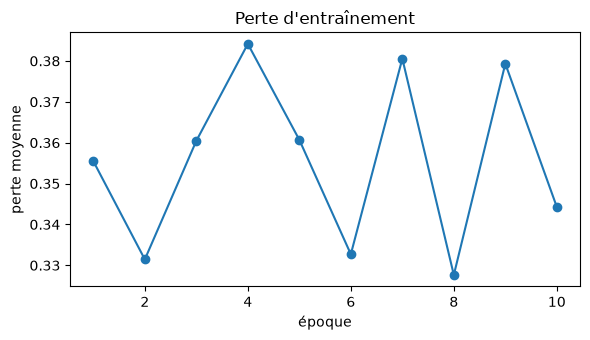

[0.355, 0.331, 0.36, 0.384, 0.361, 0.333, 0.381, 0.328, 0.379, 0.344]


In [2]:
import torch

ckpt = torch.load("../../models/plaques_baseline.pt", map_location="cpu", weights_only=True)
pertes = ckpt["historique_pertes"]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(pertes) + 1), pertes, marker="o")
ax.set_xlabel("époque"); ax.set_ylabel("perte moyenne")
ax.set_title("Perte d'entraînement")
plt.tight_layout(); plt.show()
print([round(p, 3) for p in pertes])

## 2. Rappel et précision sur la validation

Le split 346/87 est **par image** (identité des voitures non documentée — limite ADR DL 0001), reproduit ici à l'identique grâce à la graine 42 stockée dans le checkpoint.

In [3]:
exemples = charger_annotations("../../data/plaques/raw")
train, val = split_train_val(exemples, config["part_val"], config["graine"])
print(f"validation : {len(val)} images, {sum(len(e['boites']) for e in val)} plaques")

preds_val = predire(modele, device, val)
verites_val = [e["boites"] for e in val]

for seuil_score in (0.3, 0.5, 0.7):
    r = evaluer(preds_val, verites_val, seuil_iou=0.5, seuil_score=seuil_score)
    print(f"score ≥ {seuil_score} : rappel {r['rappel']:.3f} | précision {r['precision']:.3f} "
          f"(VP {r['VP']}, FP {r['FP']}, FN {r['FN']})")

validation : 87 images, 97 plaques


score ≥ 0.3 : rappel 0.876 | précision 0.904 (VP 85, FP 9, FN 12)
score ≥ 0.5 : rappel 0.866 | précision 0.966 (VP 84, FP 3, FN 13)
score ≥ 0.7 : rappel 0.856 | précision 0.965 (VP 83, FP 3, FN 14)


## 3. Courbe précision/rappel

En balayant le **seuil de score** (la confiance minimale pour garder une prédiction), on arbitre : seuil bas → rappel haut mais plus de faux positifs. Pour le floutage, on choisira un seuil **bas** — rater une plaque coûte plus cher qu'un flou en trop. Le seuil définitif sera fixé en Phase 3 sur les photos réelles.

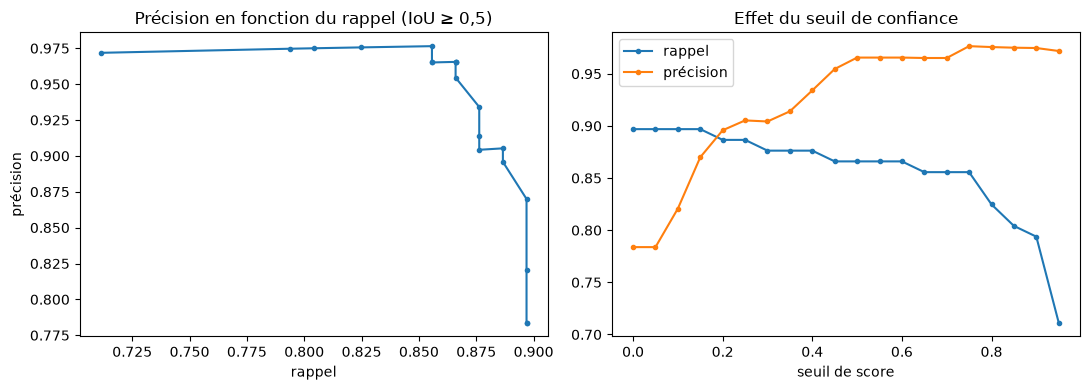

In [4]:
points = courbe_precision_rappel(preds_val, verites_val, seuil_iou=0.5)
seuils, rappels, precisions = zip(*points)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rappels, precisions, marker=".")
axes[0].set_xlabel("rappel"); axes[0].set_ylabel("précision")
axes[0].set_title("Précision en fonction du rappel (IoU ≥ 0,5)")
axes[1].plot(seuils, rappels, marker=".", label="rappel")
axes[1].plot(seuils, precisions, marker=".", label="précision")
axes[1].set_xlabel("seuil de score"); axes[1].legend()
axes[1].set_title("Effet du seuil de confiance")
plt.tight_layout(); plt.show()

## 4. Contrôle visuel

12 images de validation : **vert** = vérité annotée, **rouge** = prédictions (score ≥ 0,5). On cherche à l'œil les plaques ratées (le vrai coût RGPD) et les faux positifs typiques (calandres, panneaux, textes).

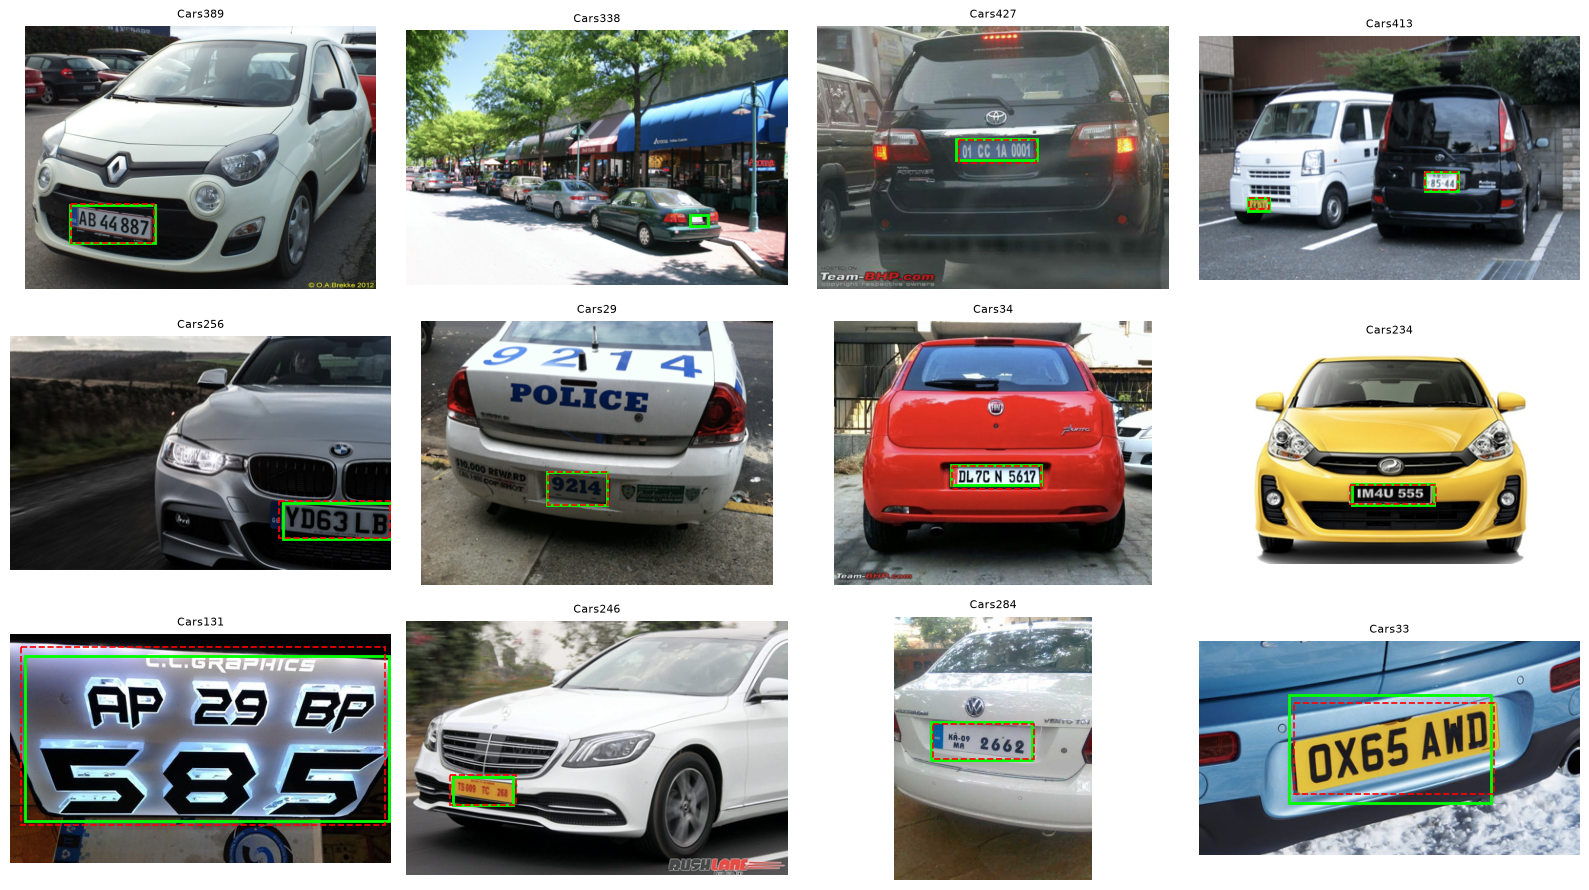

In [5]:
from matplotlib.patches import Rectangle
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, ex, preds in zip(axes.flat, val[:12], preds_val[:12]):
    ax.imshow(Image.open(ex["image"]).convert("RGB"))
    for b in ex["boites"]:
        ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                               fill=False, edgecolor="lime", linewidth=2))
    for b, s in preds:
        if s >= 0.5:
            ax.add_patch(Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1],
                                   fill=False, edgecolor="red", linewidth=1.2, linestyle="--"))
    ax.set_title(ex["image"].stem, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Résumé

La cellule suivante imprime le bilan chiffré de la baseline. À retenir avant de s'enthousiasmer : validation **interne** (même dataset international, mêmes conditions de prise de vue). La Phase 3 mesurera le **transfert** sur 200 photos leboncoin annotées en aveugle — c'est là que l'arc précédent était mort (ROC 0,509), c'est là que celui-ci se jugera.

In [6]:
r05 = evaluer(preds_val, verites_val, seuil_iou=0.5, seuil_score=0.5)
r03 = evaluer(preds_val, verites_val, seuil_iou=0.5, seuil_score=0.3)
print("=== BASELINE PLAQUES — validation interne (87 images) ===")
print(f"Modèle : {config['modele']} | device entraînement : cpu | époques : {config['epoques']}")
print(f"Rappel @IoU 0,5 / score 0,5 : {r05['rappel']:.3f} (précision {r05['precision']:.3f})")
print(f"Rappel @IoU 0,5 / score 0,3 : {r03['rappel']:.3f} (précision {r03['precision']:.3f})")
print("Prochaine étape : Phase 3 — transfert mesuré sur lot leboncoin (ADR DL 0002)")

=== BASELINE PLAQUES — validation interne (87 images) ===
Modèle : fasterrcnn_mobilenet_v3_large_fpn | device entraînement : cpu | époques : 10
Rappel @IoU 0,5 / score 0,5 : 0.866 (précision 0.966)
Rappel @IoU 0,5 / score 0,3 : 0.876 (précision 0.904)
Prochaine étape : Phase 3 — transfert mesuré sur lot leboncoin (ADR DL 0002)
